In [3]:
# NOTE:
# if your want to use your own video
# When you run the code, you can observe pixel coordinates (e.g., using mouse movement).
# Based on those coordinates, adjust the values in the region_of_interest() function
# so the selected area correctly matches the lane region in your video.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# OPTIONAL: mouse callback to print pixel coordinates
def show_coordinates(event, x, y, flags, param):
    if event == cv2.EVENT_MOUSEMOVE:
        print(f"X: {x}, Y: {y}")

def make_coordinates(image, line_parameters):
    # line_parameters contains slope (m) and intercept (b)
    slope, intercept = line_parameters
    
    y1 = image.shape[0]                # bottom of the image
    y2 = int(y1 * (3/4))               # a point 3/4 up the image
    
    # Using line equation: x = (y - b) / m
    x1 = int((y1 - intercept) / slope) # x at bottom
    x2 = int((y2 - intercept) / slope) # x at top
    
    return np.array([x1, y1, x2, y2])

def average_slope_intercept(image, lines):
    left_fit = []   # store left lane lines (negative slope)
    right_fit = []  # store right lane lines (positive slope)

    if lines is None:
        return None  # no lines detected

    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        
        # fit line (y = mx + b)
        parameters = np.polyfit((x1, x2), (y1, y2), 1)
        slope, intercept = parameters
        
        # classify lines into left or right
        if slope < 0:
            left_fit.append((slope, intercept))
        else:
            right_fit.append((slope, intercept))

    left_line = None
    right_line = None

    # average left lines
    if left_fit:
        left_fit_average = np.average(left_fit, axis=0)
        left_line = make_coordinates(image, left_fit_average)

    # average right lines
    if right_fit:
        right_fit_average = np.average(right_fit, axis=0)
        right_line = make_coordinates(image, right_fit_average)

    lines = []

    if left_line is not None:
        lines.append(left_line)
    if right_line is not None:
        lines.append(right_line)

    if lines:
        return np.array(lines)
    else:
        return None

def canny(image):
    # convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    
    # detect edges using Canny
    canny = cv2.Canny(blur, 50, 150)
    
    return canny

def display_of_lines(image, lines):
    # create blank image same size as original
    line_image = np.zeros_like(image)

    if lines is not None:
        for x1, y1, x2, y2 in lines:
            # draw each line
            cv2.line(line_image, (x1, y1), (x2, y2), (255,0,0), 10)

    return line_image

def region_of_interest(image):
    height = image.shape[0]

    # Define triangular region (YOU SHOULD ADJUST THIS BASED ON PIXELS)
    polygons = np.array([
        [(1000, height), (3000, height), (1500, 1000)]
    ])

    # create mask
    mask = np.zeros_like(image)

    # fill polygon area with white
    cv2.fillPoly(mask, polygons, 255)

    # apply mask
    masked_image = cv2.bitwise_and(image, mask)

    return masked_image


# Load video
cap = cv2.VideoCapture("test3.mp4")

# Create resizable window
cv2.namedWindow("result", cv2.WINDOW_NORMAL)
cv2.resizeWindow("result", 800, 600)

# Attach mouse callback to see coordinates
cv2.setMouseCallback("result", show_coordinates)

while cap.isOpened():
    ret, frame = cap.read()
    
    if not ret:
        break

    # Step 1: edge detection
    canny_image = canny(frame)

    # Step 2: apply region mask
    cropped_image = region_of_interest(canny_image)

    # Step 3: detect lines using Hough Transform
    lines = cv2.HoughLinesP(
        cropped_image,
        2,
        np.pi / 180,
        100,
        np.array([]),
        minLineLength=40,
        maxLineGap=5
    )

    # Step 4: average lines into left & right lanes
    averaged_lines = average_slope_intercept(frame, lines)

    # Step 5: draw lines
    line_image = display_of_lines(frame, averaged_lines)

    # Step 6: overlay lines on original frame
    combo_image = cv2.addWeighted(frame, 0.8, line_image, 1, 1)

    # Show result
    cv2.imshow("result", combo_image)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'line'
> Overload resolution failed:
>  - Can't parse 'pt1'. Sequence item with index 0 has a wrong type
>  - Can't parse 'pt1'. Sequence item with index 0 has a wrong type


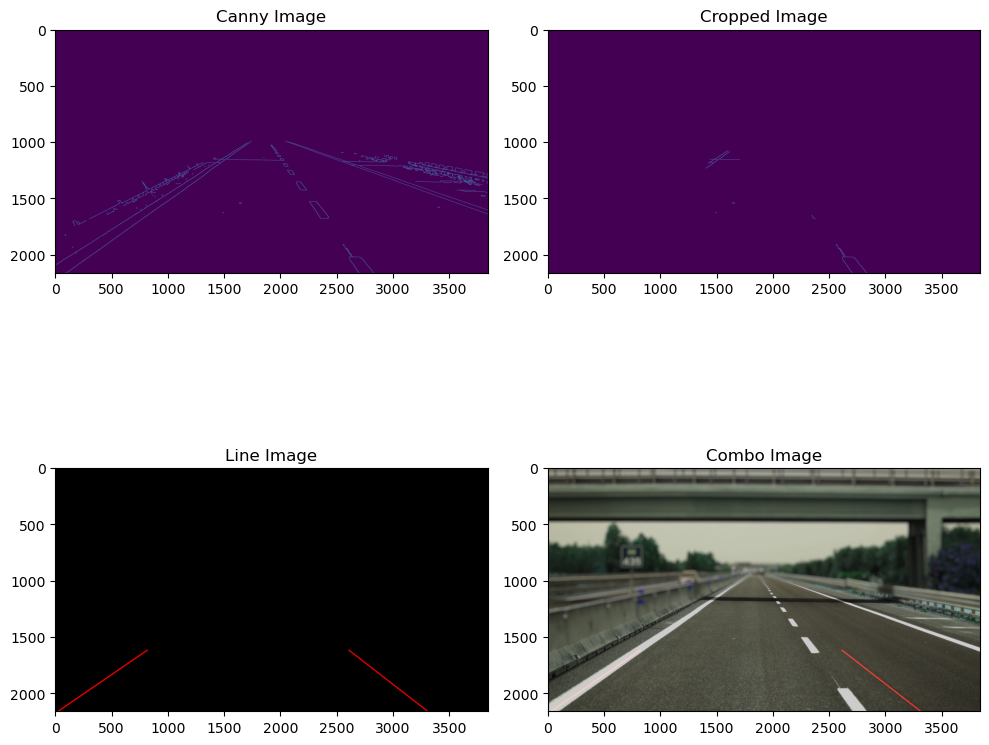

In [4]:
import matplotlib.pyplot as plt

# Use your actual images
images = [canny_image, cropped_image, line_image, combo_image]
titles = ["Canny Image", "Cropped Image", "Line Image", "Combo Image"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("on")  # show axes

plt.tight_layout()
plt.show()
